# Data Exploration
This notebook is just for loading and exploring the data required for the project.

- Available xcube data stores: https://xcube.readthedocs.io/en/latest/dataaccess.html#available-data-stores
- Documentation on accessing them: https://deepesdl.readthedocs.io/en/latest/datasets/datastores/#xcube-sentinel-hub-data-store

**Notes:**
- It may be useful to create a datacube (xcube) with the dimension "label" that contains all event masks.
- all functions should be a useful part of a pipeline, i.e. they should be able to be called in a sequence.


**New approach. First, try for one event:**
- get coordinates of pixels that have data
- sample pixels (or even use all if there are not too many)
- get data for each sampled pixel (variables that describe the event and the state of the environment)
- pca plots
- clustering -> do the clusters correspond to the groups (disturbed, undisturbed, enhanced)?

**TODO:**
- plot_kndvi_time_series_with_baseline() doesn't plotthe event kndvi anymore, what's wrong?

In [1]:
# Standard libraries
import pandas as pd
import numpy as np
import xarray as xr

# Handling files
import requests
import zipfile
import tempfile
import io
import os
import glob

# Acces APIs
import cdsapi
from xcube.core.store import new_data_store

# Plotting  
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Handling dates
import datetime
from datetime import timedelta

# Import own functions
from utils import event_sampling
from utils import event_visualization


## 1. Dheed database on extreme events

#### Load and prepare dataframe

In [ ]:
# URL
url_chd_summary = "https://zenodo.org/records/14884254/files/MergedEventStats_landonly_int.csv.zip?download=1"

# Download the ZIP file
response = requests.get(url_chd_summary)
response.raise_for_status()

# Unzip the content
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    csv_filename = z.namelist()[0]
    with z.open(csv_filename) as f:
        df_chd_summary = pd.read_csv(f)

# Create new column 'duration_days' with numeric values
df_chd_summary['duration_days'] = df_chd_summary['duration'].str.extract(r'(\d+)').astype(int)

# Convert start_time and end_time to datetime
df_chd_summary['start_time'] = pd.to_datetime(df_chd_summary['start_time'])
df_chd_summary['end_time'] = pd.to_datetime(df_chd_summary['end_time'])

#### Explore the dataframe of event summaries

Number of events 3 days long: 49079
Number of events 4 days long: 16175
Number of events longer than 16 days: 579


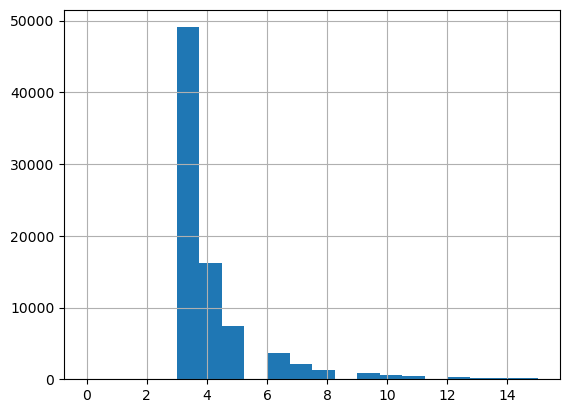

In [3]:
# Make histogram of event durations
df_chd_summary['duration_days'].hist(bins=20, range=(0,15))   

# Print number of events 3 days long
print(f"Number of events 3 days long: {len(df_chd_summary[df_chd_summary['duration_days'] == 3])}")

# Print number of days 4 days long
print(f"Number of events 4 days long: {len(df_chd_summary[df_chd_summary['duration_days'] == 4])}")

# Print number of days longer than or 16 days long
print(f"Number of events longer than 16 days: {len(df_chd_summary[df_chd_summary['duration_days'] >= 16])}") # This will be my threshold for meaningful events

### Filter relevant events
We want to remove events that are too short to be meaningful. Threshold is 16 days since we want to have at least 2 data points per event (8 day resolution).

Also, the Dheed database includes events that are outside of the period that kndvi data has. Thus, we will also remove these events.

In [11]:
# Filter dataframe for event duration
df_chd_filtered = df_chd_summary[df_chd_summary['duration_days'] >= 18]

# Filter dataframe for period of ESDC data
df_chd_filtered = df_chd_filtered[
    (df_chd_filtered['start_time'].dt.year >= 1979) &
    (df_chd_filtered['start_time'].dt.year <= 2021) &
    (df_chd_filtered['end_time'].dt.year >= 1979) &
    (df_chd_filtered['end_time'].dt.year <= 2021)
]

print(len(df_chd_filtered))

# Show DataFrame 
df_chd_filtered.sort_values('duration_days', ascending=False).head(10)


288


,label,start_time,end_time,longitude_min,longitude_max,latitude_min,latitude_max,t2mmax_mean,t2mmax_min,t2mmax_max,...,compound,land_share,inth,intd30,intd90,intd180,volume,duration,area,duration_days
5052,30070,1983-01-04,1983-05-04,282.50,284.00,-14.50,-11.25,27.407830,26.397285,30.425872,...,100.0,100.0,59.696506,43.440558,39.864617,13.228912,104.923692,121 days,0.867138,121
56,50443,1998-01-31,1998-05-16,114.50,118.75,-1.50,6.75,34.651010,27.513314,40.656169,...,100.0,100.0,7083.975414,5587.145087,5944.699343,3801.426485,9443.515568,106 days,89.089770,106
259,50825,1998-02-28,1998-05-25,264.25,282.50,7.25,18.50,34.908089,24.317658,42.772464,...,100.0,100.0,2052.822284,1100.594391,1706.801474,743.984776,2973.747773,87 days,34.181009,87
32,51134,1998-03-09,1998-06-02,80.00,124.25,3.00,23.25,37.532787,29.303954,45.047949,...,100.0,100.0,9406.044778,5832.636927,8547.628776,5259.366887,13916.438946,86 days,161.819058,86
10,105411,2016-02-27,2016-05-20,92.75,118.25,3.00,23.50,38.429633,29.907460,45.535502,...,100.0,100.0,16248.457214,10882.885354,11231.448425,4240.130612,22975.648359,84 days,273.519623,84
4416,50197,1998-01-09,1998-03-18,283.75,284.00,-14.00,-13.25,29.147717,26.793793,34.262860,...,100.0,100.0,86.528513,38.182742,71.220587,54.150539,125.292277,69 days,1.815830,69
321,51283,1998-03-14,1998-05-18,122.25,126.00,5.75,9.25,34.198372,28.320783,41.442542,...,100.0,100.0,1792.110008,1578.908361,1614.403801,852.000667,2439.491755,66 days,36.961996,66
2247,100731,2015-07-14,2015-09-16,286.00,287.50,18.25,18.50,32.880938,29.240437,36.768260,...,100.0,100.0,218.550028,139.169701,181.245710,62.101517,304.527434,65 days,4.685037,65
178,104887,2016-02-09,2016-04-11,281.50,289.25,6.75,11.00,36.907783,22.837075,43.576030,...,100.0,100.0,2804.125332,957.145596,2107.004000,68.015374,3891.942409,63 days,61.776864,63
4830,30071,1983-01-19,1983-03-22,289.25,290.25,-26.75,-20.50,25.954444,20.663064,31.170000,...,100.0,100.0,61.801473,10.402215,31.416457,1.192180,111.493362,63 days,1.769736,63


In [8]:
np.mean(df_chd_filtered['duration_days'])

np.float64(23.662591687041566)

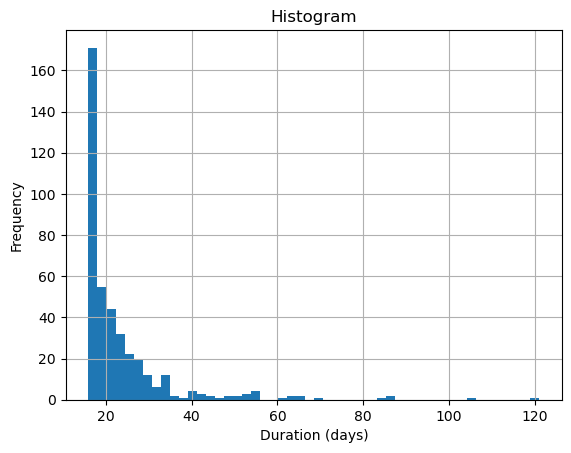

In [7]:
np.median(df_chd_filtered['duration_days']
          )

#histogram of duration_days
df_chd_filtered['duration_days'].hist(bins=50)
plt.xlabel('Duration (days)')
plt.ylabel('Frequency')
plt.title('Histogram')
plt.show()

### Create event mask

**TODO:**
- find way to not have to extract the data on my machine but to access it directly from zenodo as this is also working with the csv

#### Option 1: load label cube from zenodo (can be omitted for simplicity)

In [11]:
# Load label cube (dataset deep extremes labels)
url_chd_labels = 'https://zenodo.org/records/14884254/files/mergedlabels_ranked_pot0.01_ne0.1_cmp_S1_T3_1950_2023.zarr.zip?download=1'

# Download the ZIP file
response = requests.get(url_chd_labels)
zip_bytes = io.BytesIO(response.content)

# Extract ZIP to a temporary directory
with zipfile.ZipFile(zip_bytes, 'r') as zip_ref:
    zip_ref.extractall('data/temp_zarr_extracted') # Extracts on my local disk

# Extract the Zarr store directory
extracted_items = os.listdir('temp_zarr_extracted')
zarr_store_path = os.path.join('temp_zarr_extracted', extracted_items[0])

# Open the Zarr dataset
ds_chd_labels = xr.open_zarr(zarr_store_path, consolidated=False)

ds_chd_labels

FileNotFoundError: [Errno 2] No such file or directory: 'temp_zarr_extracted'

#### Option 2: load label cube from disk

In [7]:
# Open zarr dataset
ds_chd_labels = xr.open_zarr('data/temp_zarr_extracted/mergedlabels_ranked_pot0.01_ne0.1_cmp_S1_T3_1950_2023.zarr', consolidated=False)

ds_chd_labels

<xarray.Dataset> Size: 224GB
Dimensions:    (Ti: 27028, latitude: 721, longitude: 1440)
Coordinates:
  * Ti         (Ti) datetime64[ns] 216kB 1950-01-01 1950-01-02 ... 2023-12-31
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Data variables:
    labels     (Ti, latitude, longitude) float64 224GB dask.array<chunksize=(90, 120, 120), meta=np.ndarray>

#### Load land mask from NASAs GLAD
This land mask is required for the funciton create_event_mask to properly crop the event mask to land-only data. The land mask used is the [GLDAS Land/Sea Mask](https://ldas.gsfc.nasa.gov/gldas/vegetation-class-mask) from NASA.

In [8]:
landmask_url = "https://ldas.gsfc.nasa.gov/sites/default/files/ldas/gldas/VEG/GLDASp5_landmask_025d.nc4"

# Download file locally
path_landmask = "data/GLDASp5_landmask_025d.nc4"
with requests.get(landmask_url, stream=True) as r:
    r.raise_for_status()
    with open(path_landmask, 'wb') as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)

# Open with xarray
ds_landmask = xr.open_dataset(path_landmask)

# Open the right variable as land mask
landmask = ds_landmask['GLDAS_mask']

In [10]:
# Create event area mask WITHOUT LAND CROPPING
event_mask_105411 = event_sampling.create_event_mask(105411, event_table=df_chd_filtered, labelcube=ds_chd_labels, land_mask=landmask)

In [11]:
event_mask_83007 = event_sampling.create_event_mask(83007, event_table=df_chd_filtered, labelcube=ds_chd_labels, land_mask=landmask)

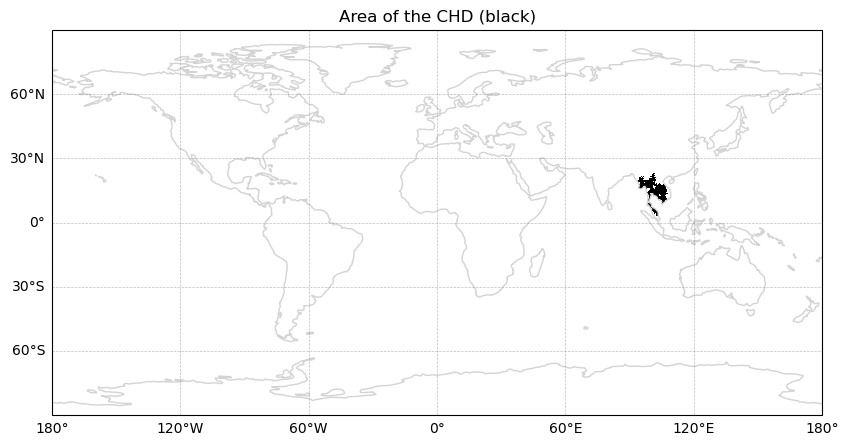

In [12]:
 # Plot core area mask
plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
event_mask_105411.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='binary', add_colorbar=False)
ax.set_title("Area of the CHD (black)")
ax.coastlines(color='lightgrey')

# Add coordinate grid
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

plt.show()

## 2. Earth System Data Cube
Since it seems impossible to use MODIS data for daily kNDVI calulation, I will start with ESDC data first. I will see if for one large event, there is already a response in the TS for kNDVI.

In [12]:
# Load Earth System Data Cube store
store = new_data_store("s3", root="deep-esdl-public", storage_options=dict(anon=True))
ds_esdc = store.open_data('esdc-8d-0.25deg-1x720x1440-3.0.1.zarr')

### kNDVI preparation

In [13]:
# Load kNDVI from data store
kndvi = ds_esdc['kndvi']

In [14]:
kndvi_array_105411 = event_sampling.create_event_dataarray(kndvi, event_mask_105411, df_chd_filtered, 105411, 60)
kndvi_array_105411

NameError: name 'event_mask_105411' is not defined

In [16]:
kndvi_array_83007 = event_sampling.create_event_dataarray(kndvi, event_mask_83007, df_chd_filtered, 83007, 60)
kndvi_array_83007

<xarray.DataArray 'kndvi' (time: 171, lat: 158, lon: 280)> Size: 30MB
dask.array<getitem, shape=(171, 158, 280), dtype=float32, chunksize=(1, 158, 280), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 1kB 31.12 31.38 31.62 31.88 ... 69.88 70.12 70.38
  * lon      (lon) float64 2kB -0.375 -0.125 0.125 0.375 ... 68.88 69.12 69.38
  * time     (time) datetime64[ns] 1kB 2010-05-05 2010-05-05 ... 2010-10-20
Attributes: (12/25)
    acknowledgment:             https://lpdaac.usgs.gov/products/mcd43c4v061/
    date_modified:              2022-10-11 23:51:00.603768
    description:                MODIS/Terra+Aqua BRDF/Albedo Nadir BRDF-Adjus...
    geospatial_lat_max:         89.875
    geospatial_lat_min:         -89.87499999998977
    geospatial_lat_resolution:  0.25
    ...                         ...
    standard_name:              kNDVI
    temporal_resolution:        8D
    time_coverage_end:          2021-12-31T00:00:00.000000000
    time_coverage_start:        2000-03-01T00:00:00.000000000
    time_period:                8D
    units:                      1

#### Visualization: plot a specific day of the event
This is to see, where the data is. This can help to find coordinates for time series plotting using the function _plot_time_series_.

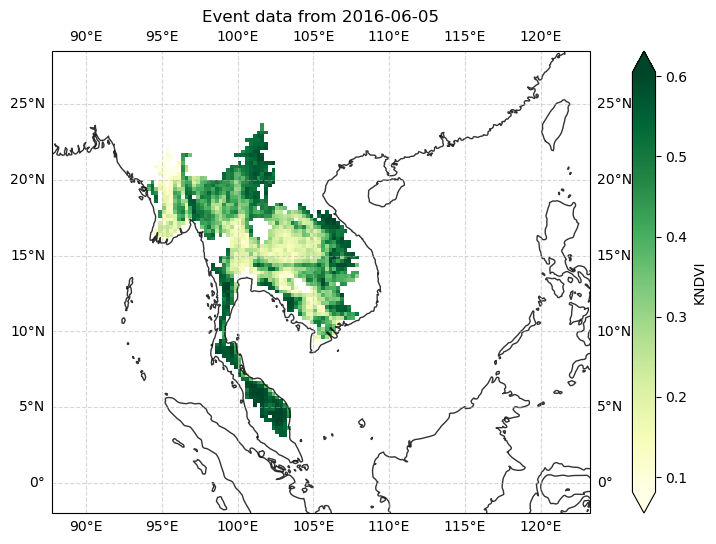

In [17]:
event_visualization.plot_event_day(kndvi_array_105411, 20)

#### Create a dataframe that has all the coordintes of pixels that actually have values (i.e. are part of the event)

In [18]:
coordinates_105411 = event_sampling.get_data_pixel_coordinates(kndvi_array_105411)

In [19]:
coordinates_83007 = event_sampling.get_data_pixel_coordinates(kndvi_array_83007)

#### Plot time series for 10 random samples of the event pixels
May have to remove trend and seasonality before these small time series can be interpreted. Also maybe a longer time window before and after the TS.

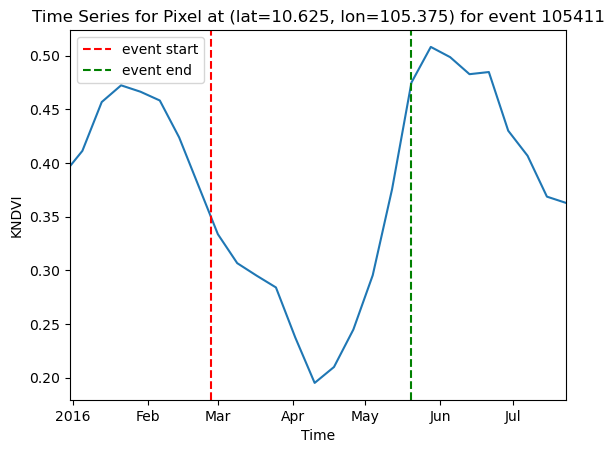

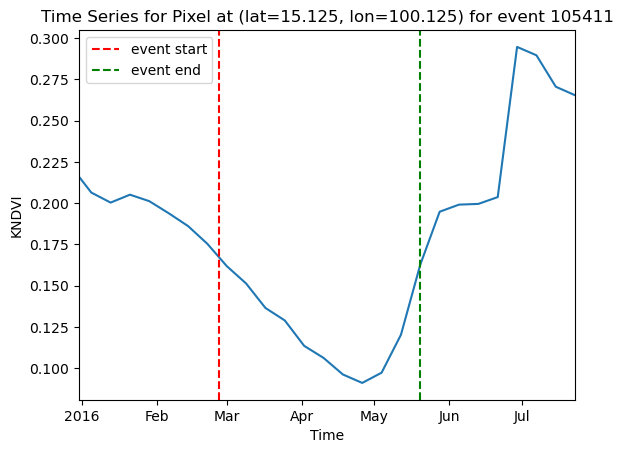

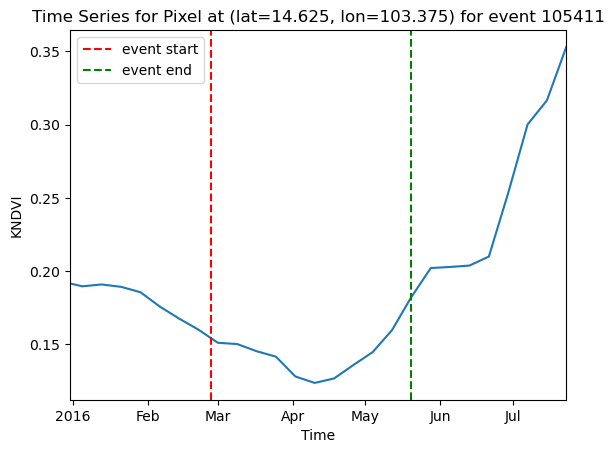

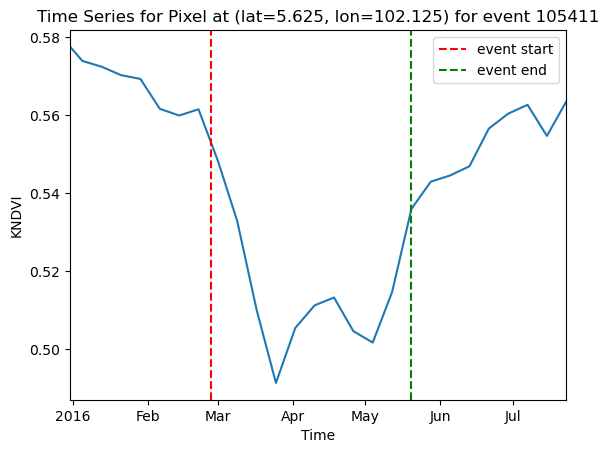

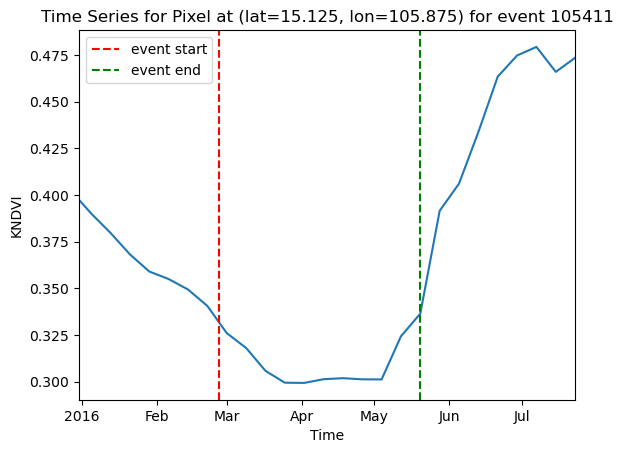

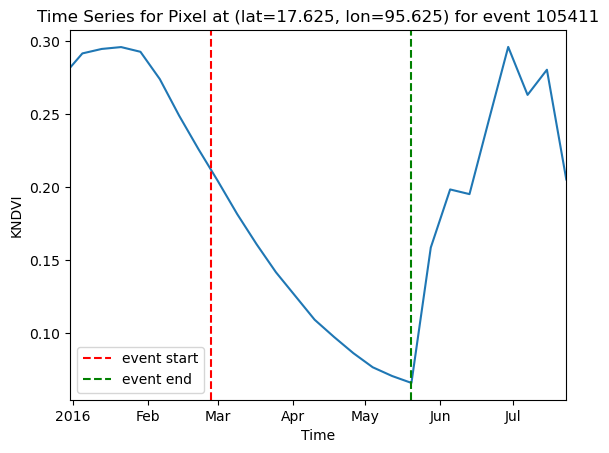

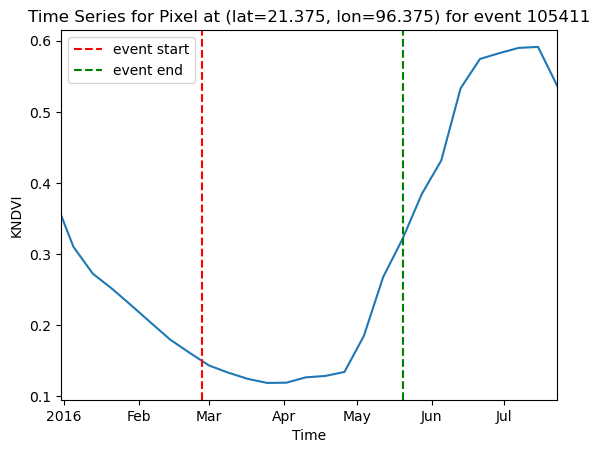

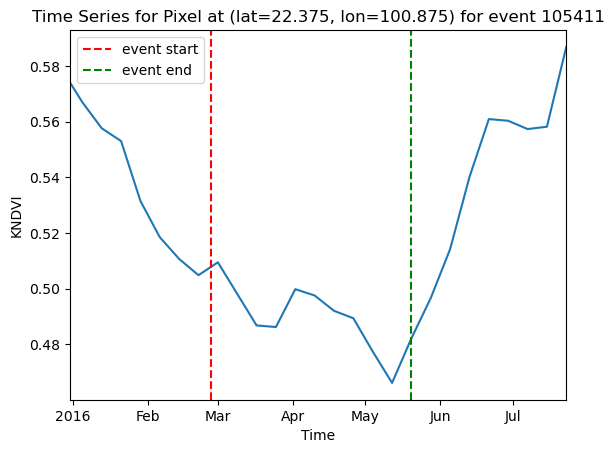

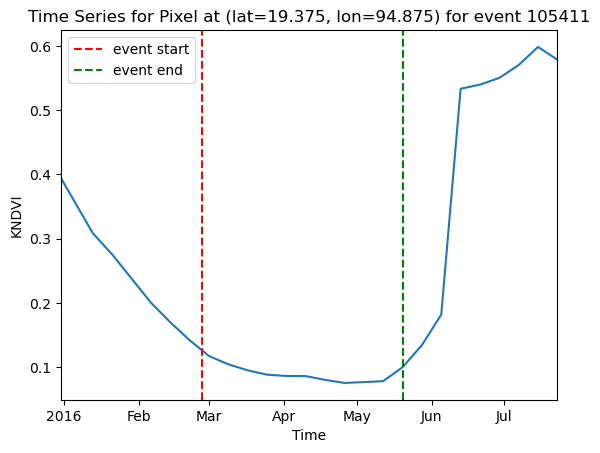

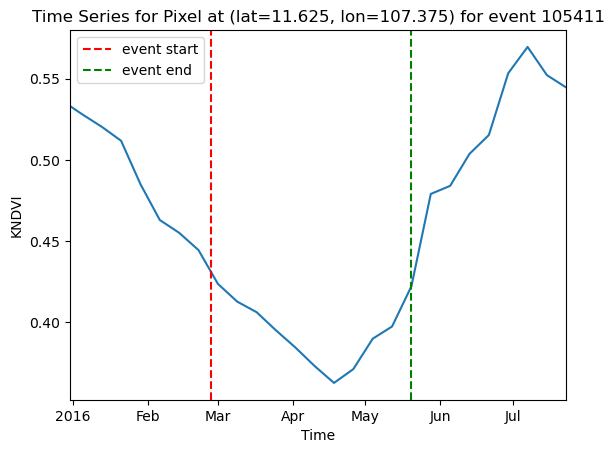

In [20]:
# Get 10 random locations from coordinates_105411 and plit kndvi time series for each of them
random_coordinates_105411 = coordinates_105411.sample(10, random_state=42)

for index, row in random_coordinates_105411.iterrows():
    event_visualization.plot_kndvi_time_series(kndvi_array_105411, lat=row['lat'], lon=row['lon'], event_label=105411, event_table=df_chd_filtered)


#### Compare to average of the same period

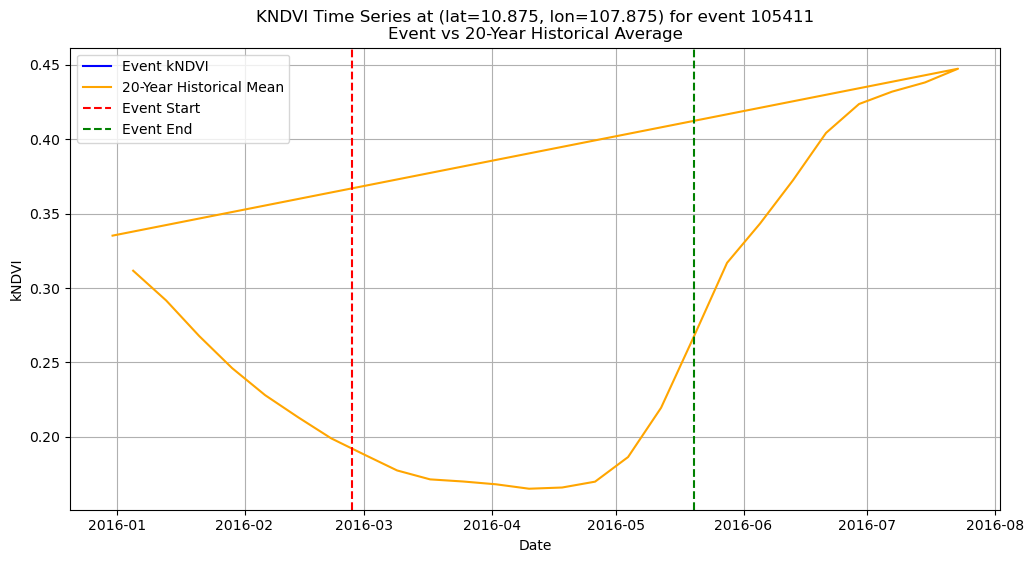

In [21]:
event_visualization.plot_kndvi_time_series_with_baseline( 
    event_array=kndvi_array_105411,
    lat=10.875,
    lon=107.875,
    event_label=105411,
    event_table=df_chd_filtered,
    full_kndvi_data=kndvi
)

## Playground: aggregation

### load and plot vegetation mask

In [ ]:
vegetation_url = "https://ldas.gsfc.nasa.gov/sites/default/files/ldas/gldas/VEG/GLDASp5_domveg_NOAH3.6_025d.nc4"


# Download file locally
path_vegetationmask = "data/GLDASp5_domveg_NOAH3.6_025d.nc4"
with requests.get(vegetation_url, stream=True) as r:
    r.raise_for_status()
    with open(path_vegetationmask, 'wb') as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)

# Open with xarray
ds_vegetationmask = xr.open_dataset(path_vegetationmask)

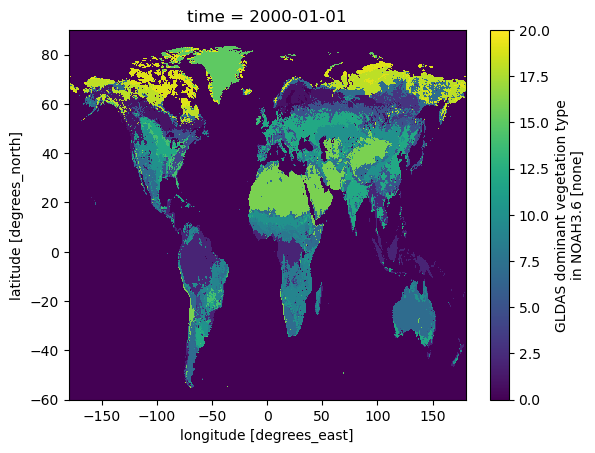

In [11]:
ds_vegetationmask['GLDAS_domveg'].plot()

In [ ]:
# Load csv to translate class labels to class names
legend = pd.read_csv("data/GLDA_veg_legend.csv", index_col=0)
legend

,missing value
0,
1,Evergreen Needleleaf Forest
2,Evergreen Broadleaf Forest
3,Deciduous Needleleaf Forest
4,Deciduous Broadleaf Forest
5,Mixed Forest
6,Closed Shrublands
7,Open Shrublands
8,Woody Savannas
9,Savannas


Most basic form: average one kndvi value per land cover class